In [1]:
!pip install xgboost joblib -q 2>&1 | tail -3


In [2]:
import os, sys, time, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

warnings.filterwarnings("ignore")
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# === Regression Risk Scoring ===
# Adapted for regression: measures how much adversarial noise degrades predictions.
# Components:
#   - r2_drop: (clean_R2 - adv_R2) / max(clean_R2, 0.01) -- normalized R2 degradation
#   - rmse_increase: (adv_RMSE - clean_RMSE) / clean_RMSE -- relative RMSE blow-up
#   - prediction_shift: mean(|adv_pred - clean_pred|) / std(y_test) -- normalized mean shift
#   - max_shift: max(|adv_pred - clean_pred|) / std(y_test) -- worst-case shift
#
# score = 0.30 * clamp(r2_drop, 0, 1) + 0.25 * clamp(rmse_increase, 0, 1)
#       + 0.25 * clamp(prediction_shift, 0, 1) + 0.20 * clamp(max_shift, 0, 1)
# Threshold = 0.5

REG_W = {"r2_drop": 0.30, "rmse_increase": 0.25, "pred_shift": 0.25, "max_shift": 0.20}
REG_THRESHOLD = 0.5

def compute_reg_risk_score(clean_r2, adv_r2, clean_rmse, adv_rmse,
                            clean_preds, adv_preds, y_std):
    r2_drop = (clean_r2 - adv_r2) / max(clean_r2, 0.01)
    rmse_inc = (adv_rmse - clean_rmse) / max(clean_rmse, 1e-6)
    pred_shift = np.mean(np.abs(adv_preds - clean_preds)) / max(y_std, 1e-6)
    max_s = np.max(np.abs(adv_preds - clean_preds)) / max(y_std, 1e-6)

    score = (REG_W["r2_drop"] * min(max(r2_drop, 0), 1)
           + REG_W["rmse_increase"] * min(max(rmse_inc, 0), 1)
           + REG_W["pred_shift"] * min(max(pred_shift, 0), 1)
           + REG_W["max_shift"] * min(max(max_s, 0), 1))
    gate = "BLOCK" if score > REG_THRESHOLD else "PASS"
    return score, gate, {"r2_drop": r2_drop, "rmse_increase": rmse_inc,
                         "pred_shift": pred_shift, "max_shift": max_s}


Device: cpu


## 1 — Data Preparation

California Housing: predict median house value (continuous, in $100K units).
8 numerical features. 70/15/15 split.


In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print(f"Dataset: {df.shape}")
print(f"Target: {data.target_names}")
print(f"Features: {data.feature_names}")
print()
print(df.describe().round(2))

X_raw = df.drop(columns=["MedHouseVal"]).values
y_raw = df["MedHouseVal"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

# Target stats for normalization
y_std = y_test.std()
y_mean = y_test.mean()

# Feature clamping bounds
X_train_min = X_train.min(axis=0)
X_train_max = X_train.max(axis=0)

N_FEATURES = X_train.shape[1]
print(f"Train={X_train.shape[0]} | Val={X_val.shape[0]} | Test={X_test.shape[0]}")
print(f"Features: {N_FEATURES}")
print(f"Target mean={y_mean:.3f} | std={y_std:.3f} | range=[{y_raw.min():.2f}, {y_raw.max():.2f}]")


Dataset: (20640, 9)
Target: ['MedHouseVal']
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35   

## 2 — Model Definitions


In [4]:
import xgboost as xgb

# Candidate 1: Ridge Regression
reg_ridge = Ridge(alpha=1.0, random_state=SEED)

# Candidate 2: XGBoost Regressor
reg_xgb = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=SEED, verbosity=0)

# Candidate 3: Feedforward NN for regression
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

reg_nn = RegressionNN(N_FEATURES).to(device)

reg_model_meta = {
    "Ridge": {"params": "after_fit", "flops": "N/A"},
    "XGBoost": {"params": "200 trees", "flops": "N/A"},
    "RegressionNN": {"params": sum(p.numel() for p in reg_nn.parameters()), "flops": "N/A"}
}
print(f"RegressionNN params: {reg_model_meta['RegressionNN']['params']:,}")


RegressionNN params: 11,969


## 3 — Training All Three Models


In [5]:
reg_histories = {}

# --- Ridge ---
print("=" * 60)
print("Training: Ridge")
print("=" * 60)
t0 = time.time()
reg_ridge.fit(X_train, y_train)
ridge_t = time.time() - t0
ridge_val_pred = reg_ridge.predict(X_val)
ridge_val_r2 = r2_score(y_val, ridge_val_pred)
ridge_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_pred))
ridge_p = reg_ridge.coef_.size + 1
reg_model_meta["Ridge"]["params"] = ridge_p
joblib.dump(reg_ridge, "outputs/models/reg_ridge.pkl")
ridge_ck = os.path.getsize("outputs/models/reg_ridge.pkl") / 1024**2
reg_histories["Ridge"] = {
    "total_time": ridge_t, "peak_vram_mb": 0, "ckpt_size_mb": ridge_ck,
    "best_val_metric": ridge_val_r2, "train_loss": [], "val_loss": [],
    "epoch_time": [ridge_t], "has_curves": False}
print(f"  Done -- {ridge_t:.1f}s | Val R2: {ridge_val_r2:.4f} | Val RMSE: {ridge_val_rmse:.4f}")

# --- XGBoost ---
print()
print("=" * 60)
print("Training: XGBoost")
print("=" * 60)
t0 = time.time()
reg_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_t = time.time() - t0
xgb_val_pred = reg_xgb.predict(X_val)
xgb_val_r2 = r2_score(y_val, xgb_val_pred)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_trees = sum(1 for _ in reg_xgb.get_booster().get_dump())
reg_model_meta["XGBoost"]["params"] = f"{xgb_trees} trees"
joblib.dump(reg_xgb, "outputs/models/reg_xgboost.pkl")
xgb_ck = os.path.getsize("outputs/models/reg_xgboost.pkl") / 1024**2
reg_histories["XGBoost"] = {
    "total_time": xgb_t, "peak_vram_mb": 0, "ckpt_size_mb": xgb_ck,
    "best_val_metric": xgb_val_r2, "train_loss": [], "val_loss": [],
    "epoch_time": [xgb_t], "has_curves": False}
print(f"  Done -- {xgb_t:.1f}s | Val R2: {xgb_val_r2:.4f} | Val RMSE: {xgb_val_rmse:.4f}")

# --- RegressionNN ---
print()
print("=" * 60)
print("Training: RegressionNN")
print("=" * 60)
REG_EPOCHS = 100
reg_train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32))
reg_val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32))
reg_train_loader = DataLoader(reg_train_ds, batch_size=256, shuffle=True)
reg_val_loader = DataLoader(reg_val_ds, batch_size=256, shuffle=False)

opt_rnn = optim.Adam(reg_nn.parameters(), lr=1e-3)
crit_rnn = nn.MSELoss()
sched_rnn = optim.lr_scheduler.CosineAnnealingLR(opt_rnn, T_max=REG_EPOCHS)

nn_hist = {"train_loss": [], "val_loss": [], "val_r2": [], "epoch_time": [], "lr": []}
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
total_start = time.time()

for epoch in range(REG_EPOCHS):
    ep_start = time.time()
    reg_nn.train()
    rl, to = 0.0, 0
    for Xb, yb in reg_train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_rnn.zero_grad()
        out = reg_nn(Xb)
        loss = crit_rnn(out, yb)
        loss.backward()
        opt_rnn.step()
        rl += loss.item() * Xb.size(0)
        to += Xb.size(0)
    tl = rl / to

    reg_nn.eval()
    vl, vt = 0.0, 0
    val_preds_list = []
    val_labels_list = []
    with torch.no_grad():
        for Xb, yb in reg_val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = reg_nn(Xb)
            vl += crit_rnn(out, yb).item() * Xb.size(0)
            vt += Xb.size(0)
            val_preds_list.extend(out.cpu().numpy())
            val_labels_list.extend(yb.cpu().numpy())
    vlo = vl / vt
    vr2 = r2_score(val_labels_list, val_preds_list)
    sched_rnn.step()
    et = time.time() - ep_start

    nn_hist["train_loss"].append(tl)
    nn_hist["val_loss"].append(vlo)
    nn_hist["val_r2"].append(vr2)
    nn_hist["epoch_time"].append(et)
    nn_hist["lr"].append(sched_rnn.get_last_lr()[0])

    if (epoch+1) % 20 == 0 or epoch == 0:
        print(f"  [RegressionNN] Epoch {epoch+1:3d}/{REG_EPOCHS} | "
              f"Train MSE: {tl:.4f} | Val MSE: {vlo:.4f} | Val R2: {vr2:.4f} | {et:.1f}s")

nn_tt = time.time() - total_start
nn_pv = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0
torch.save(reg_nn.state_dict(), "outputs/models/reg_nn.pth")
nn_ck = os.path.getsize("outputs/models/reg_nn.pth") / 1024**2
nn_hist["total_time"] = nn_tt
nn_hist["peak_vram_mb"] = nn_pv
nn_hist["best_val_metric"] = max(nn_hist["val_r2"])
nn_hist["ckpt_size_mb"] = nn_ck
nn_hist["has_curves"] = True
reg_histories["RegressionNN"] = nn_hist
print(f"  [RegressionNN] Done -- {nn_tt:.1f}s | Best Val R2: {nn_hist['best_val_metric']:.4f}")


Training: Ridge
  Done -- 0.0s | Val R2: 0.6135 | Val RMSE: 0.7190

Training: XGBoost
  Done -- 3.0s | Val R2: 0.8372 | Val RMSE: 0.4667

Training: RegressionNN
  [RegressionNN] Epoch   1/100 | Train MSE: 4.0229 | Val MSE: 2.8463 | Val R2: -1.1282 | 1.8s
  [RegressionNN] Epoch  20/100 | Train MSE: 0.3516 | Val MSE: 0.6677 | Val R2: 0.5008 | 0.5s
  [RegressionNN] Epoch  40/100 | Train MSE: 0.3260 | Val MSE: 0.5975 | Val R2: 0.5532 | 0.5s
  [RegressionNN] Epoch  60/100 | Train MSE: 0.3061 | Val MSE: 0.5882 | Val R2: 0.5602 | 0.7s
  [RegressionNN] Epoch  80/100 | Train MSE: 0.3043 | Val MSE: 0.5157 | Val R2: 0.6144 | 0.6s
  [RegressionNN] Epoch 100/100 | Train MSE: 0.3030 | Val MSE: 0.6292 | Val R2: 0.5295 | 0.5s
  [RegressionNN] Done -- 57.2s | Best Val R2: 0.7366


## 4 — Learning Curves


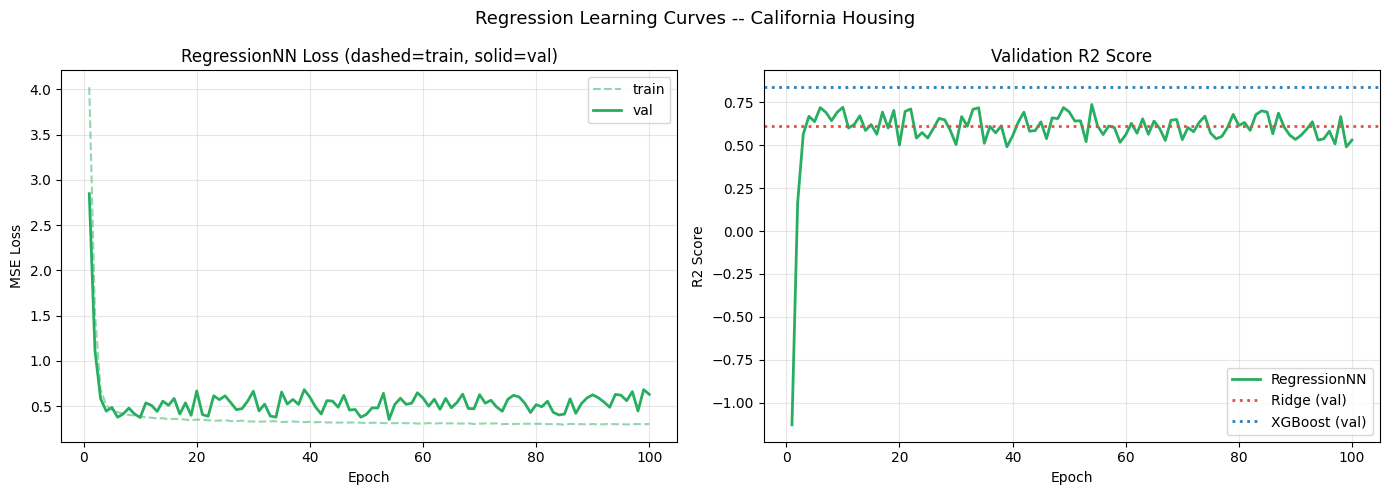

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_colors = {"Ridge": "#e74c3c", "XGBoost": "#2980b9", "RegressionNN": "#27ae60"}

h = reg_histories["RegressionNN"]
er = range(1, len(h["train_loss"]) + 1)
axes[0].plot(er, h["train_loss"], "--", color=reg_colors["RegressionNN"], alpha=0.5, label="train")
axes[0].plot(er, h["val_loss"], "-", color=reg_colors["RegressionNN"], label="val", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("RegressionNN Loss (dashed=train, solid=val)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(er, h["val_r2"], "-", color=reg_colors["RegressionNN"], label="RegressionNN", linewidth=2)
axes[1].axhline(y=reg_histories["Ridge"]["best_val_metric"], color=reg_colors["Ridge"],
                linestyle=":", linewidth=2, label="Ridge (val)")
axes[1].axhline(y=reg_histories["XGBoost"]["best_val_metric"], color=reg_colors["XGBoost"],
                linestyle=":", linewidth=2, label="XGBoost (val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("R2 Score")
axes[1].set_title("Validation R2 Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Regression Learning Curves -- California Housing", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/regression_learning_curves.png", dpi=150)
plt.show()


## 5 — Test Set Evaluation


In [7]:
reg_test_results = {}

for name, model, is_sk in [("Ridge", reg_ridge, True), ("XGBoost", reg_xgb, True), ("RegressionNN", reg_nn, False)]:
    if is_sk:
        preds = model.predict(X_test)
    else:
        model.eval()
        with torch.no_grad():
            preds = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    reg_test_results[name] = {"rmse": rmse, "mae": mae, "r2": r2, "preds": preds}
    print(f"{name} -- R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")


Ridge -- R2: 0.5901 | RMSE: 0.7329 | MAE: 0.5354
XGBoost -- R2: 0.8346 | RMSE: 0.4656 | MAE: 0.3068
RegressionNN -- R2: 0.5192 | RMSE: 0.7938 | MAE: 0.5177


## 6 — Prediction vs Actual Scatter Plots


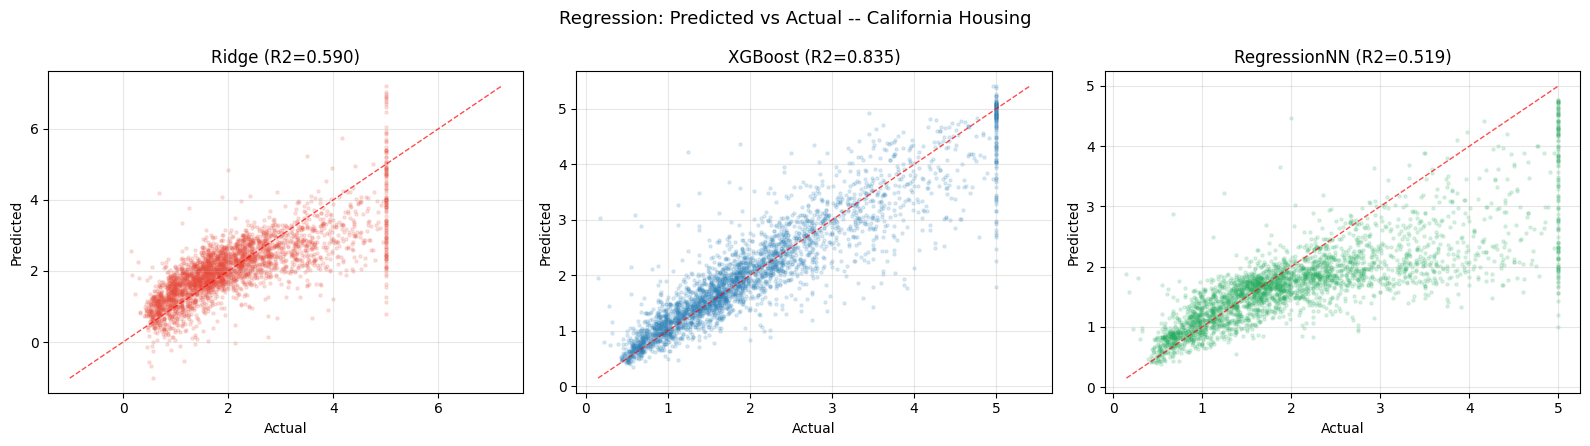

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for idx, (name, res) in enumerate(reg_test_results.items()):
    ax = axes[idx]
    ax.scatter(y_test, res["preds"], alpha=0.15, s=5, color=reg_colors.get(name, "#333"))
    lims = [min(y_test.min(), res["preds"].min()), max(y_test.max(), res["preds"].max())]
    ax.plot(lims, lims, "r--", linewidth=1, alpha=0.7)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} (R2={res['r2']:.3f})")
    ax.grid(alpha=0.3)
plt.suptitle("Regression: Predicted vs Actual -- California Housing", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/regression_scatter.png", dpi=150)
plt.show()


## 7 — Adversarial Attacks (Regression)

Gaussian noise perturbations at sigma=0.1 and sigma=0.5.
All perturbed features clamped to training-set [min, max].
200 test samples per model per attack.
Regression risk scoring uses R2 drop, RMSE increase, prediction shift, and max shift.


In [9]:
REG_ATK_N = 200
sample_idx = random.sample(range(len(X_test)), REG_ATK_N)
X_reg_sample = X_test[sample_idx]
y_reg_sample = y_test[sample_idx]

def reg_noise_attack(X, sigma=0.1):
    noise = np.random.normal(0, sigma, X.shape)
    return np.clip(X + noise, X_train_min, X_train_max)

reg_atk_configs = {
    "Noise_0.1": lambda X: reg_noise_attack(X, sigma=0.1),
    "Noise_0.5": lambda X: reg_noise_attack(X, sigma=0.5),
}

reg_adv_results = {}

for name, model, is_sk in [("Ridge", reg_ridge, True), ("XGBoost", reg_xgb, True), ("RegressionNN", reg_nn, False)]:
    reg_adv_results[name] = {}
    print()
    print("=" * 60)
    print(f"Attacking: {name}")
    print("=" * 60)

    if is_sk:
        clean_preds = model.predict(X_reg_sample)
    else:
        model.eval()
        with torch.no_grad():
            clean_preds = model(torch.tensor(X_reg_sample, dtype=torch.float32).to(device)).cpu().numpy()

    clean_rmse = np.sqrt(mean_squared_error(y_reg_sample, clean_preds))
    clean_r2 = r2_score(y_reg_sample, clean_preds)

    for atk_name, atk_fn in reg_atk_configs.items():
        t0 = time.time()
        X_adv = atk_fn(X_reg_sample)

        if is_sk:
            adv_preds = model.predict(X_adv)
        else:
            with torch.no_grad():
                adv_preds = model(torch.tensor(X_adv, dtype=torch.float32).to(device)).cpu().numpy()

        adv_rmse = np.sqrt(mean_squared_error(y_reg_sample, adv_preds))
        adv_r2 = r2_score(y_reg_sample, adv_preds)
        adv_mae = mean_absolute_error(y_reg_sample, adv_preds)
        elapsed = time.time() - t0

        risk_score, gate, components = compute_reg_risk_score(
            clean_r2, adv_r2, clean_rmse, adv_rmse, clean_preds, adv_preds, y_std)

        reg_adv_results[name][atk_name] = {
            "clean_r2": clean_r2, "adv_r2": adv_r2,
            "clean_rmse": clean_rmse, "adv_rmse": adv_rmse,
            "adv_mae": adv_mae, "risk_score": risk_score, "gate": gate,
            "components": components, "attack_time_s": elapsed}
        print(f"  {atk_name}: R2 {clean_r2:.4f}->{adv_r2:.4f} | "
              f"RMSE {clean_rmse:.4f}->{adv_rmse:.4f} | "
              f"Risk={risk_score:.4f} [{gate}] | {elapsed:.1f}s")



Attacking: Ridge
  Noise_0.1: R2 0.5636->0.5414 | RMSE 0.8105->0.8310 | Risk=0.1408 [PASS] | 0.0s
  Noise_0.5: R2 0.5636->0.1818 | RMSE 0.8105->1.1099 | Risk=0.6250 [BLOCK] | 0.0s

Attacking: XGBoost
  Noise_0.1: R2 0.8518->0.4854 | RMSE 0.4724->0.8802 | Risk=0.6470 [BLOCK] | 0.0s
  Noise_0.5: R2 0.8518->-0.2118 | RMSE 0.4724->1.3508 | Risk=0.9536 [BLOCK] | 0.0s

Attacking: RegressionNN
  Noise_0.1: R2 0.4944->0.4808 | RMSE 0.8725->0.8841 | Risk=0.1232 [PASS] | 0.0s
  Noise_0.5: R2 0.4944->0.3398 | RMSE 0.8725->0.9970 | Risk=0.4196 [PASS] | 0.0s


## 8 — Adversarial Impact Visualization


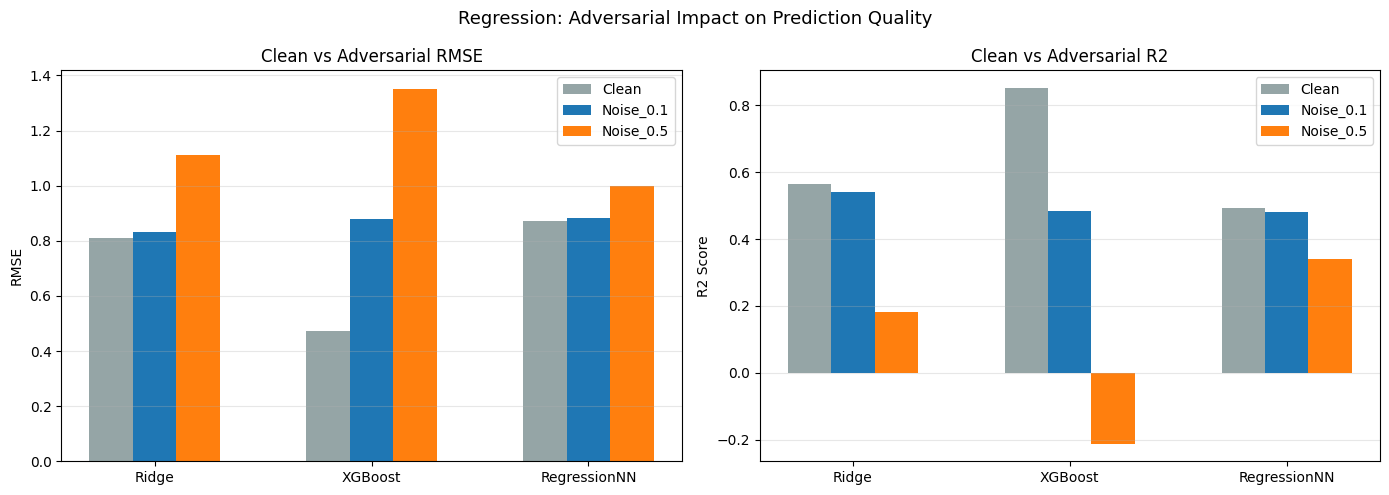

In [10]:
# Bar chart: clean vs adversarial RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = list(reg_adv_results.keys())
attacks = list(reg_atk_configs.keys())

bar_w = 0.2
x = np.arange(len(models))

# RMSE comparison
clean_rmses = [reg_adv_results[m][attacks[0]]["clean_rmse"] for m in models]
axes[0].bar(x - bar_w, clean_rmses, bar_w, label="Clean", color="#95a5a6")
for i, atk in enumerate(attacks):
    vals = [reg_adv_results[m][atk]["adv_rmse"] for m in models]
    axes[0].bar(x + i * bar_w, vals, bar_w, label=atk)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Clean vs Adversarial RMSE")
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

# R2 comparison
clean_r2s = [reg_adv_results[m][attacks[0]]["clean_r2"] for m in models]
axes[1].bar(x - bar_w, clean_r2s, bar_w, label="Clean", color="#95a5a6")
for i, atk in enumerate(attacks):
    vals = [reg_adv_results[m][atk]["adv_r2"] for m in models]
    axes[1].bar(x + i * bar_w, vals, bar_w, label=atk)
axes[1].set_ylabel("R2 Score")
axes[1].set_title("Clean vs Adversarial R2")
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Regression: Adversarial Impact on Prediction Quality", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/regression_adversarial_comparison.png", dpi=150)
plt.show()


## 9 — Risk Score Heatmap


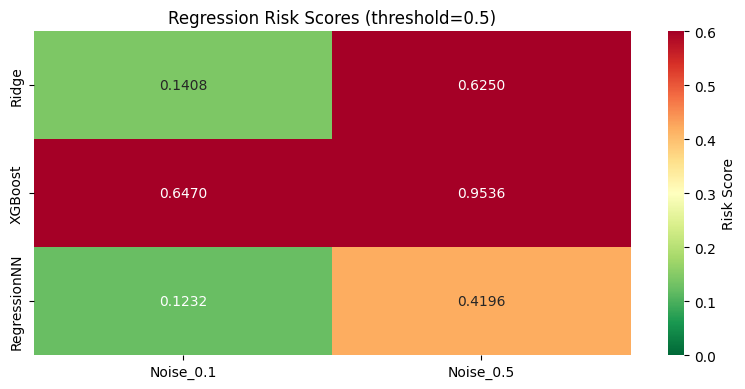

In [11]:
models_list = list(reg_adv_results.keys())
attacks_list = list(list(reg_adv_results.values())[0].keys())
risk_matrix = np.array([[reg_adv_results[m][a]["risk_score"] for a in attacks_list] for m in models_list])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(risk_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=attacks_list, yticklabels=models_list,
            vmin=0, vmax=0.6, ax=ax, cbar_kws={"label": "Risk Score"})
ax.set_title("Regression Risk Scores (threshold=0.5)")
plt.tight_layout()
plt.savefig("outputs/plots/regression_risk_heatmap.png", dpi=150)
plt.show()


## 10 — Inference Benchmarks


In [12]:
reg_inf_results = {}

for name, model, is_sk in [("Ridge", reg_ridge, True), ("XGBoost", reg_xgb, True), ("RegressionNN", reg_nn, False)]:
    latencies = []
    for i in range(min(500, len(X_test))):
        sample = X_test[i:i+1]
        if is_sk:
            t0 = time.perf_counter()
            _ = model.predict(sample)
            latencies.append((time.perf_counter() - t0) * 1000)
        else:
            model.eval()
            x_t = torch.tensor(sample, dtype=torch.float32).to(device)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.no_grad():
                _ = model(x_t)
            if device.type == "cuda":
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)

    if is_sk:
        ts = time.time()
        _ = model.predict(X_test)
        tp = len(X_test) / (time.time() - ts)
        vram = 0
    else:
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        X_all = torch.tensor(X_test, dtype=torch.float32).to(device)
        ts = time.time()
        with torch.no_grad():
            _ = model(X_all)
        if device.type == "cuda":
            torch.cuda.synchronize()
        tp = len(X_test) / (time.time() - ts)
        vram = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0

    reg_inf_results[name] = {
        "p50_ms": np.percentile(latencies, 50),
        "p90_ms": np.percentile(latencies, 90),
        "throughput_sps": tp,
        "inf_vram_mb": vram}
    print(f"{name}: p50={reg_inf_results[name]['p50_ms']:.2f}ms | "
          f"p90={reg_inf_results[name]['p90_ms']:.2f}ms | "
          f"throughput={tp:.0f} samp/s | VRAM={vram:.0f}MB")


Ridge: p50=0.19ms | p90=0.25ms | throughput=11042147 samp/s | VRAM=0MB
XGBoost: p50=0.70ms | p90=1.21ms | throughput=229245 samp/s | VRAM=0MB
RegressionNN: p50=0.19ms | p90=0.23ms | throughput=804010 samp/s | VRAM=0MB


## 11 — Summary Table


In [13]:
rows = []
for name in ["Ridge", "XGBoost", "RegressionNN"]:
    h = reg_histories[name]; t = reg_test_results[name]
    m = reg_model_meta[name]; inf = reg_inf_results[name]
    worst_atk = max(reg_adv_results[name].items(), key=lambda x: x[1]["risk_score"])
    p = m["params"]
    pstr = f"{p:,}" if isinstance(p, int) else str(p)
    rows.append({
        "Model": name, "Params": pstr,
        "Train Time": f"{h['total_time']:.0f}s",
        "Test R2": f"{t['r2']:.4f}",
        "Test RMSE": f"{t['rmse']:.4f}",
        "Test MAE": f"{t['mae']:.4f}",
        "Worst Risk": f"{worst_atk[1]['risk_score']:.4f}",
        "Gate": worst_atk[1]["gate"],
        "p50 (ms)": f"{inf['p50_ms']:.2f}",
        "Throughput": f"{inf['throughput_sps']:.0f}"})

summary_df = pd.DataFrame(rows)
summary_df.to_csv("outputs/regression_summary.csv", index=False)
print("=" * 80)
print("REGRESSION SUMMARY -- ROBUSTOPS MILESTONE 2")
print("=" * 80)
print(summary_df.to_string(index=False))


REGRESSION SUMMARY -- ROBUSTOPS MILESTONE 2
       Model    Params Train Time Test R2 Test RMSE Test MAE Worst Risk  Gate p50 (ms) Throughput
       Ridge         9         0s  0.5901    0.7329   0.5354     0.6250 BLOCK     0.19   11042147
     XGBoost 200 trees         3s  0.8346    0.4656   0.3068     0.9536 BLOCK     0.70     229245
RegressionNN    11,969        57s  0.5192    0.7938   0.5177     0.4196  PASS     0.19     804010
